# MODIS Chip CNN / U-Net for OCO-2 SIF

This notebook trains a small U-Net-style CNN on the 16x16 MODIS-scale chips prepared from FAPAR, EVI, NDVI, PAR, crop fractions, month, latitude, and longitude.

The model predicts a 16x16 SIF map. Because true pixel-level SIF is unavailable, training compares only the footprint-mask-weighted average prediction against the observed OCO-2 SIF value.

## 1. Setup

In [22]:
from collections import OrderedDict
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

## 2. Config

In [23]:
CHIP_DIR = Path("/kaggle/input/datasets/vishalt11/cnn-modis-chips-8day/cnn_modis_chips/modis_8day_250m_16x16")
#CHIP_DIR = Path("/kaggle/input/CNN_Modis_Chips_8day/cnn_modis_chips/modis_8day_250m_16x16")
METADATA_PATH = CHIP_DIR / "chip_metadata.csv"

TARGET_COL = "Daily_SIF_740nm"

# Filtering: keep these loose at first because your valid fractions looked healthy.
MIN_FAPAR_VALID = 0.90
MIN_EVI_VALID = 0.90
MIN_NDVI_VALID = 0.90
MIN_PAR_VALID = 0.01

# Split options: "random_stratified" or "year".
SPLIT_MODE = "random_stratified"
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Used only when SPLIT_MODE = "year".
TRAIN_YEARS = [2019, 2020, 2021, 2022]
VAL_YEARS = [2023]
TEST_YEARS = [2024]

#BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

BATCH_SIZE = 512
NUM_WORKERS = 2
SHARD_CACHE_SIZE = 32

# Keep DataLoader workers at 0 on Windows while the dataset uses its own shard cache.
#NUM_WORKERS = 0
#SHARD_CACHE_SIZE = 12

# Channel stats are computed from this many training samples. Increase later if desired.
#MAX_SAMPLES_FOR_STATS = 20000
MAX_SAMPLES_FOR_STATS = 5000
NORMALIZE_TARGET = True

MODEL_OUT = Path("/kaggle/working/small_unet_modis_sif.pt")
PREDICTIONS_OUT = Path("/kaggle/working/test_predictions.csv")

## 3. Load Metadata and Shard Index

In [24]:
def build_shard_index(chip_dir: Path) -> tuple[pd.DataFrame, list[str]]:
    shard_files = sorted(chip_dir.glob("chips_*.npz"))
    if not shard_files:
        raise FileNotFoundError(f"No chip shards found in {chip_dir}")

    rows = []
    channel_names = None
    sample_order = 0

    for shard_id, shard_path in enumerate(shard_files):
        with np.load(shard_path, allow_pickle=False) as z:
            sif_ids = z["sif_row_id"]
            if channel_names is None:
                channel_names = [str(x) for x in z["channel_names"]]

            for local_index, sif_row_id in enumerate(sif_ids):
                rows.append({
                    "sample_order": sample_order,
                    "shard_id": shard_id,
                    "shard_path": str(shard_path),
                    "local_index": local_index,
                    "sif_row_id_key": str(sif_row_id),
                })
                sample_order += 1

    shard_index = pd.DataFrame(rows)

    duplicated = shard_index[shard_index.duplicated("sif_row_id_key", keep=False)]
    if len(duplicated) > 0:
        raise ValueError(
            "Duplicate sif_row_id values found across shards. "
            "This usually means old shard files are mixed with a newer run. "
            "Clear the chip output directory and regenerate chips."
        )

    return shard_index, channel_names


metadata = pd.read_csv(METADATA_PATH)
metadata["sif_row_id_key"] = metadata["sif_row_id"].astype(str)

shard_index, channel_names = build_shard_index(CHIP_DIR)
samples = metadata.merge(shard_index, on="sif_row_id_key", how="inner")

print("metadata rows:", len(metadata))
print("indexed chip rows:", len(shard_index))
print("merged rows:", len(samples))
print("channels:", channel_names)

if len(samples) != len(metadata):
    print("Warning: metadata and shard rows do not match exactly. Check for stale shard files or missing chips.")

samples.head()

metadata rows: 179354
indexed chip rows: 179354
merged rows: 179354
channels: ['fapar', 'evi', 'ndvi', 'par', 'apar', 'winter_wheat_fraction', 'winter_barley_fraction', 'rapeseed_fraction', 'maize_fraction', 'grassland_fraction', 'other_crop_fraction', 'non_crop_fraction', 'month_sin', 'month_cos', 'latitude', 'longitude']


,sif_row_id,Delta_Date,state,sif_year,sif_doy,composite_doy,composite_start_date,composite_end_date,composite_day_offset,Daily_SIF_740nm,...,rapeseed_fraction_valid_fraction,maize_fraction_valid_fraction,grassland_fraction_valid_fraction,other_crop_fraction_valid_fraction,non_crop_fraction_valid_fraction,sif_row_id_key,sample_order,shard_id,shard_path,local_index
0,1140,2019-02-08,BADEN-WÜRTTEMBERG,2019,39,33,2019-02-02,2019-02-09,6,0.115658,...,1.0,1.0,1.0,1.0,1.0,1140,0,0,/kaggle/input/datasets/vishalt11/cnn-modis-chi...,0
1,1142,2019-02-08,BADEN-WÜRTTEMBERG,2019,39,33,2019-02-02,2019-02-09,6,0.238108,...,1.0,1.0,1.0,1.0,1.0,1142,1,0,/kaggle/input/datasets/vishalt11/cnn-modis-chi...,1
2,1145,2019-02-08,BADEN-WÜRTTEMBERG,2019,39,33,2019-02-02,2019-02-09,6,0.052446,...,1.0,1.0,1.0,1.0,1.0,1145,2,0,/kaggle/input/datasets/vishalt11/cnn-modis-chi...,2
3,1146,2019-02-08,BADEN-WÜRTTEMBERG,2019,39,33,2019-02-02,2019-02-09,6,0.194089,...,1.0,1.0,1.0,1.0,1.0,1146,3,0,/kaggle/input/datasets/vishalt11/cnn-modis-chi...,3
4,1147,2019-02-08,BADEN-WÜRTTEMBERG,2019,39,33,2019-02-02,2019-02-09,6,0.228795,...,1.0,1.0,1.0,1.0,1.0,1147,4,0,/kaggle/input/datasets/vishalt11/cnn-modis-chi...,4


## 4. Filter Samples

In [25]:
before = len(samples)

samples = samples[
    samples[TARGET_COL].notna()
    & (samples["mask_sum"] > 0)
    & (samples["fapar_valid_fraction"] >= MIN_FAPAR_VALID)
    & (samples["evi_valid_fraction"] >= MIN_EVI_VALID)
    & (samples["ndvi_valid_fraction"] >= MIN_NDVI_VALID)
    & (samples["par_valid_fraction"] >= MIN_PAR_VALID)
].copy()

samples = samples.reset_index(drop=True)

print(f"Kept {len(samples):,} / {before:,} samples after filtering")
samples[["fapar_valid_fraction", "evi_valid_fraction", "ndvi_valid_fraction", "par_valid_fraction", "mask_sum", TARGET_COL]].describe()

Kept 179,256 / 179,354 samples after filtering


,fapar_valid_fraction,evi_valid_fraction,ndvi_valid_fraction,par_valid_fraction,mask_sum,Daily_SIF_740nm
count,179256.000000,179256.000000,179256.000000,179256.000000,179256.000000,179256.000000
mean,0.999915,0.999915,0.999915,0.999595,18.136931,0.438933
std,0.002169,0.002171,0.002171,0.015271,3.630032,0.335626
min,0.902344,0.902344,0.902344,0.015625,3.968750,-1.064763
25%,1.000000,1.000000,1.000000,1.000000,15.453125,0.188099
50%,1.000000,1.000000,1.000000,1.000000,17.375000,0.411327
75%,1.000000,1.000000,1.000000,1.000000,20.687500,0.665418
max,1.000000,1.000000,1.000000,1.000000,32.171875,3.444313


## 5. Train / Validation / Test Split

In [26]:
def random_stratified_split(table: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(SEED)
    train_idx, val_idx, test_idx = [], [], []

    group_cols = ["state", "sif_year", "composite_doy"]

    for _, group in table.groupby(group_cols, sort=False):
        idx = group.index.to_numpy()
        rng.shuffle(idx)
        n = len(idx)

        if n < 3:
            train_idx.extend(idx)
            continue

        n_test = max(1, int(round(n * TEST_FRAC)))
        n_val = max(1, int(round(n * VAL_FRAC)))

        if n_test + n_val >= n:
            n_test = 1
            n_val = 1

        test_idx.extend(idx[:n_test])
        val_idx.extend(idx[n_test:n_test + n_val])
        train_idx.extend(idx[n_test + n_val:])

    return np.array(train_idx), np.array(val_idx), np.array(test_idx)


def year_split(table: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    train_idx = table.index[table["sif_year"].isin(TRAIN_YEARS)].to_numpy()
    val_idx = table.index[table["sif_year"].isin(VAL_YEARS)].to_numpy()
    test_idx = table.index[table["sif_year"].isin(TEST_YEARS)].to_numpy()
    return train_idx, val_idx, test_idx


if SPLIT_MODE == "random_stratified":
    train_idx, val_idx, test_idx = random_stratified_split(samples)
elif SPLIT_MODE == "year":
    train_idx, val_idx, test_idx = year_split(samples)
else:
    raise ValueError(f"Unknown SPLIT_MODE: {SPLIT_MODE}")

print("train:", len(train_idx))
print("val:", len(val_idx))
print("test:", len(test_idx))

split_counts = pd.Series({"train": len(train_idx), "val": len(val_idx), "test": len(test_idx)})
split_counts / split_counts.sum()

train: 125446
val: 26905
test: 26905


train    0.699815
val      0.150093
test     0.150093
dtype: float64

## 6. Dataset, Shard Cache, and Normalization

In [27]:
class ShardCache:
    def __init__(self, max_shards: int = 12):
        self.max_shards = max_shards
        self.cache = OrderedDict()

    def get(self, shard_path: str) -> dict[str, np.ndarray]:
        if shard_path in self.cache:
            self.cache.move_to_end(shard_path)
            return self.cache[shard_path]

        with np.load(shard_path, allow_pickle=False) as z:
            shard = {
                "X": z["X"].astype(np.float32),
                "footprint_mask": z["footprint_mask"].astype(np.float32),
            }

        self.cache[shard_path] = shard
        self.cache.move_to_end(shard_path)

        while len(self.cache) > self.max_shards:
            self.cache.popitem(last=False)

        return shard


class ModisChipDataset(Dataset):
    def __init__(
        self,
        table: pd.DataFrame,
        channel_mean: np.ndarray | None = None,
        channel_std: np.ndarray | None = None,
        target_mean: float | None = None,
        target_std: float | None = None,
        cache_size: int = 12,
    ):
        self.table = table.reset_index(drop=True).copy()
        self.channel_mean = channel_mean
        self.channel_std = channel_std
        self.target_mean = target_mean
        self.target_std = target_std
        self.cache = ShardCache(max_shards=cache_size)

    def __len__(self):
        return len(self.table)

    def __getitem__(self, idx: int):
        row = self.table.iloc[idx]
        shard = self.cache.get(row["shard_path"])
        local_index = int(row["local_index"])

        x = shard["X"][local_index].copy()
        mask = shard["footprint_mask"][local_index].copy()[None, :, :]
        y = np.float32(row[TARGET_COL])

        if self.channel_mean is not None and self.channel_std is not None:
            x = (x - self.channel_mean[:, None, None]) / self.channel_std[:, None, None]

        if self.target_mean is not None and self.target_std is not None:
            y = np.float32((y - self.target_mean) / self.target_std)

        return torch.from_numpy(x), torch.from_numpy(mask), torch.tensor(y, dtype=torch.float32)


def compute_channel_stats(table: pd.DataFrame, max_samples: int = 20000) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(SEED)
    if len(table) > max_samples:
        stat_table = table.iloc[rng.choice(len(table), size=max_samples, replace=False)].copy()
    else:
        stat_table = table.copy()

    ds = ModisChipDataset(stat_table, cache_size=SHARD_CACHE_SIZE)

    channel_sum = None
    channel_sumsq = None
    pixel_count = 0

    for i in range(len(ds)):
        x, _, _ = ds[i]
        arr = x.numpy()
        if channel_sum is None:
            channel_sum = np.zeros(arr.shape[0], dtype=np.float64)
            channel_sumsq = np.zeros(arr.shape[0], dtype=np.float64)

        channel_sum += arr.sum(axis=(1, 2))
        channel_sumsq += (arr ** 2).sum(axis=(1, 2))
        pixel_count += arr.shape[1] * arr.shape[2]

    mean = channel_sum / pixel_count
    var = np.maximum(channel_sumsq / pixel_count - mean ** 2, 1e-8)
    std = np.sqrt(var)
    return mean.astype(np.float32), std.astype(np.float32)


train_table = samples.loc[train_idx].reset_index(drop=True)
val_table = samples.loc[val_idx].reset_index(drop=True)
test_table = samples.loc[test_idx].reset_index(drop=True)


# Sort by shard for much faster NPZ loading on Kaggle.
train_table = train_table.sort_values(["shard_id", "local_index"]).reset_index(drop=True)
val_table = val_table.sort_values(["shard_id", "local_index"]).reset_index(drop=True)
test_table = test_table.sort_values(["shard_id", "local_index"]).reset_index(drop=True)

channel_mean, channel_std = compute_channel_stats(train_table, max_samples=MAX_SAMPLES_FOR_STATS)

if NORMALIZE_TARGET:
    target_mean = float(train_table[TARGET_COL].mean())
    target_std = float(train_table[TARGET_COL].std())
else:
    target_mean = None
    target_std = None

stats_df = pd.DataFrame({"channel": channel_names, "mean": channel_mean, "std": channel_std})
display(stats_df)
print("target_mean:", target_mean)
print("target_std:", target_std)

,channel,mean,std
0,fapar,0.599572,0.153098
1,evi,0.422262,0.129305
2,ndvi,0.694543,0.129093
3,par,89.117516,44.374474
4,apar,55.932076,34.127773
5,winter_wheat_fraction,0.071688,0.198466
6,winter_barley_fraction,0.039139,0.143935
7,rapeseed_fraction,0.034226,0.144242
8,maize_fraction,0.074195,0.193214
9,grassland_fraction,0.124536,0.240650


target_mean: 0.43859812146103766
target_std: 0.33579881859858196


## 7. DataLoaders

In [28]:
train_ds = ModisChipDataset(
    train_table,
    channel_mean=channel_mean,
    channel_std=channel_std,
    target_mean=target_mean,
    target_std=target_std,
    cache_size=SHARD_CACHE_SIZE,
)
val_ds = ModisChipDataset(
    val_table,
    channel_mean=channel_mean,
    channel_std=channel_std,
    target_mean=target_mean,
    target_std=target_std,
    cache_size=SHARD_CACHE_SIZE,
)
test_ds = ModisChipDataset(
    test_table,
    channel_mean=channel_mean,
    channel_std=channel_std,
    target_mean=target_mean,
    target_std=target_std,
    cache_size=SHARD_CACHE_SIZE,
)

#train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

xb, mb, yb = next(iter(train_loader))
print("X:", xb.shape)
print("mask:", mb.shape)
print("y:", yb.shape)

X: torch.Size([512, 16, 16, 16])
mask: torch.Size([512, 1, 16, 16])
y: torch.Size([512])


## 8. Model

In [29]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels: int, base_channels: int = 32):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base_channels * 2, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_channels * 2, base_channels)

        self.out = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


model = SmallUNet(in_channels=len(channel_names), base_channels=32).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model

SmallUNet(
  (enc1): ConvBlock(
    (net): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (

## 9. Masked Loss and Metrics

In [30]:
def masked_average(pred_map: torch.Tensor, footprint_mask: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    numerator = (pred_map * footprint_mask).sum(dim=(1, 2, 3))
    denominator = footprint_mask.sum(dim=(1, 2, 3)).clamp_min(eps)
    return numerator / denominator


def invert_target(y: np.ndarray) -> np.ndarray:
    if target_mean is None or target_std is None:
        return y
    return y * target_std + target_mean


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    residual = y_pred - y_true
    mse = float(np.mean(residual ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(residual)))
    bias = float(np.mean(residual))
    denom = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1.0 - np.sum(residual ** 2) / denom) if denom > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "bias": bias, "r2": r2}


@torch.no_grad()
def predict_loader(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    y_true_all = []
    y_pred_all = []

    for xb, mask, yb in loader:
        xb = xb.to(DEVICE)
        mask = mask.to(DEVICE)

        pred_map = model(xb)
        pred_sif = masked_average(pred_map, mask)

        y_true_all.append(yb.numpy())
        y_pred_all.append(pred_sif.cpu().numpy())

    y_true = invert_target(np.concatenate(y_true_all))
    y_pred = invert_target(np.concatenate(y_pred_all))
    return y_true, y_pred


def evaluate(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    y_true, y_pred = predict_loader(model, loader)
    return regression_metrics(y_true, y_pred)

## 10. Training

In [31]:
history = []
best_val_rmse = math.inf
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, mask, yb in train_loader:
        xb = xb.to(DEVICE)
        mask = mask.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred_map = model(xb)
        pred_sif = masked_average(pred_map, mask)
        loss = F.mse_loss(pred_sif, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    val_metrics = evaluate(model, val_loader)
    train_loss = float(np.mean(train_losses))

    row = {"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}}
    history.append(row)

    print(
        f"Epoch {epoch:03d} | train_loss={train_loss:.5f} | "
        f"val_rmse={val_metrics['rmse']:.5f} | val_r2={val_metrics['r2']:.4f} | "
        f"val_mae={val_metrics['mae']:.5f} | val_bias={val_metrics['bias']:.5f}"
    )

    if val_metrics["rmse"] < best_val_rmse:
        best_val_rmse = val_metrics["rmse"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.tail()

Epoch 001 | train_loss=0.82465 | val_rmse=0.29580 | val_r2=0.2263 | val_mae=0.23611 | val_bias=0.06048
Epoch 002 | train_loss=0.66598 | val_rmse=0.29234 | val_r2=0.2443 | val_mae=0.23366 | val_bias=0.10973
Epoch 003 | train_loss=0.61230 | val_rmse=0.28063 | val_r2=0.3036 | val_mae=0.22075 | val_bias=0.10894
Epoch 004 | train_loss=0.58567 | val_rmse=0.27686 | val_r2=0.3222 | val_mae=0.21852 | val_bias=0.07487
Epoch 005 | train_loss=0.58020 | val_rmse=0.27693 | val_r2=0.3219 | val_mae=0.21842 | val_bias=0.06705
Epoch 006 | train_loss=0.57704 | val_rmse=0.27818 | val_r2=0.3157 | val_mae=0.22026 | val_bias=0.08152
Epoch 007 | train_loss=0.57540 | val_rmse=0.27693 | val_r2=0.3218 | val_mae=0.21902 | val_bias=0.06450
Epoch 008 | train_loss=0.56918 | val_rmse=0.27026 | val_r2=0.3541 | val_mae=0.21160 | val_bias=0.06256
Epoch 009 | train_loss=0.56631 | val_rmse=0.27301 | val_r2=0.3409 | val_mae=0.21462 | val_bias=0.06906
Epoch 010 | train_loss=0.56467 | val_rmse=0.26911 | val_r2=0.3596 | val_m

,epoch,train_loss,val_rmse,val_mae,val_bias,val_r2
25,26,0.537204,0.281530,0.221383,0.067435,0.299144
26,27,0.535794,0.290973,0.230762,0.087855,0.251343
27,28,0.533117,0.306423,0.245023,0.098072,0.169725
28,29,0.530840,0.319130,0.255194,0.111635,0.099435
29,30,0.529659,0.318348,0.253881,0.114505,0.103844


## 11. Validation and Test Evaluation

In [32]:
val_metrics = evaluate(model, val_loader)
test_y_true, test_y_pred = predict_loader(model, test_loader)
test_metrics = regression_metrics(test_y_true, test_y_pred)

print("Validation metrics:")
print(val_metrics)
print("\nTest metrics:")
print(test_metrics)

predictions = test_table[["sif_row_id", "Delta_Date", "state", "sif_year", "sif_doy", "composite_doy", "Latitude", "Longitude"]].copy()
predictions["observed_sif"] = test_y_true
predictions["predicted_sif"] = test_y_pred
predictions["residual"] = predictions["predicted_sif"] - predictions["observed_sif"]
predictions.to_csv(PREDICTIONS_OUT, index=False)
predictions.head()

Validation metrics:
{'rmse': 0.2691119429277477, 'mae': 0.21031388640403748, 'bias': 0.057055242359638214, 'r2': 0.3596101403236389}

Test metrics:
{'rmse': 0.26934010182260276, 'mae': 0.21066007018089294, 'bias': 0.05884131044149399, 'r2': 0.350280225276947}


,sif_row_id,Delta_Date,state,sif_year,sif_doy,composite_doy,Latitude,Longitude,observed_sif,predicted_sif,residual
0,1146,2019-02-08,BADEN-WÜRTTEMBERG,2019,39,33,49.334351,10.062073,0.194089,0.227837,0.033748
1,11,2019-02-06,BAYERN,2019,37,33,47.629883,12.164917,0.181883,0.199803,0.017920
2,24,2019-02-06,BAYERN,2019,37,33,47.681824,12.126160,0.148644,0.198914,0.050269
3,45,2019-02-06,BAYERN,2019,37,33,47.773132,12.071472,0.124914,0.314629,0.189715
4,87,2019-02-06,BAYERN,2019,37,33,47.854065,12.067993,0.142454,0.214251,0.071797


## 12. Diagnostics

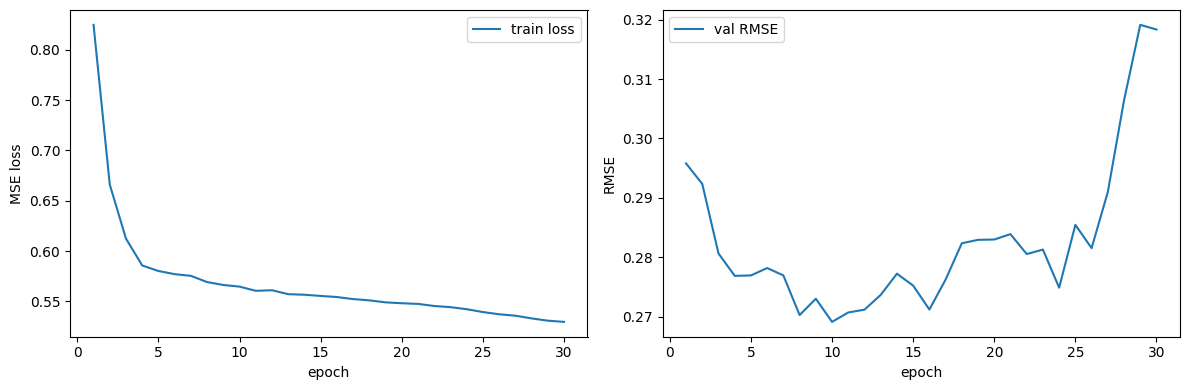

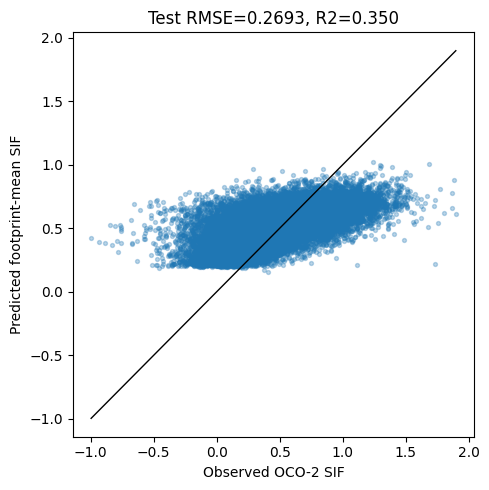

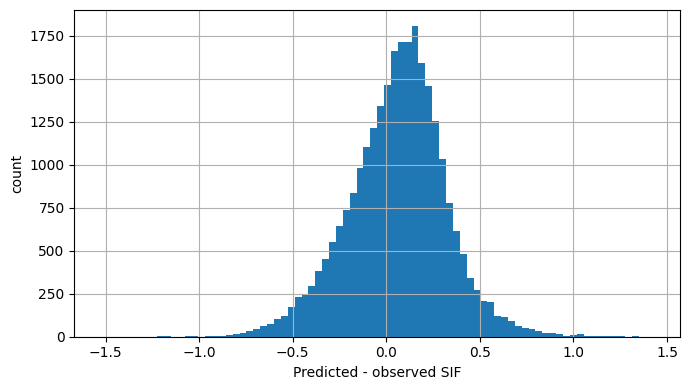

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_rmse"], label="val RMSE")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(test_y_true, test_y_pred, s=8, alpha=0.3)
lims = [min(test_y_true.min(), test_y_pred.min()), max(test_y_true.max(), test_y_pred.max())]
plt.plot(lims, lims, color="black", linewidth=1)
plt.xlabel("Observed OCO-2 SIF")
plt.ylabel("Predicted footprint-mean SIF")
plt.title(f"Test RMSE={test_metrics['rmse']:.4f}, R2={test_metrics['r2']:.3f}")
plt.tight_layout()
plt.show()

predictions["residual"].hist(bins=80, figsize=(7, 4))
plt.xlabel("Predicted - observed SIF")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 13. Inspect One Predicted Map

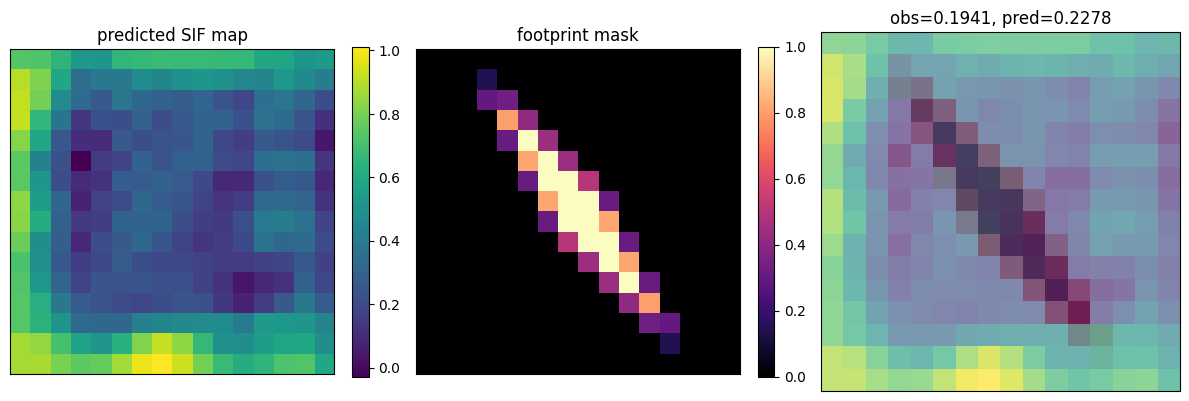

In [34]:
sample_idx = 0
model.eval()

x, mask, y = test_ds[sample_idx]
with torch.no_grad():
    pred_map_norm = model(x[None].to(DEVICE)).cpu()[0, 0].numpy()

pred_map = invert_target(pred_map_norm)
mask_np = mask[0].numpy()
pred_sif = (pred_map * mask_np).sum() / max(mask_np.sum(), 1e-6)
obs_sif = invert_target(np.array([y.item()]))[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im0 = axes[0].imshow(pred_map, cmap="viridis")
axes[0].set_title("predicted SIF map")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mask_np, cmap="magma", vmin=0, vmax=1)
axes[1].set_title("footprint mask")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].imshow(pred_map, cmap="viridis")
axes[2].imshow(mask_np, cmap="Reds", alpha=0.35, vmin=0, vmax=1)
axes[2].set_title(f"obs={obs_sif:.4f}, pred={pred_sif:.4f}")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 14. Save Model

In [35]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "channel_names": channel_names,
        "channel_mean": channel_mean,
        "channel_std": channel_std,
        "target_mean": target_mean,
        "target_std": target_std,
        "config": {
            "split_mode": SPLIT_MODE,
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
        },
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    },
    MODEL_OUT,
)

print(f"Saved model to {MODEL_OUT}")
print(f"Saved test predictions to {PREDICTIONS_OUT}")

Saved model to /kaggle/working/small_unet_modis_sif.pt
Saved test predictions to /kaggle/working/test_predictions.csv
